# Theta scaling analysis for MGD on LAGRANGIAN TURBULENCE data
Load data from an ensemble of experiments 

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from typing import Dict, Any, Tuple, Optional
import pandas as pd
from matplotlib.colors import to_rgb
from pathlib import Path
import sys
import copy
import math
from types import SimpleNamespace

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines import *
from utils import *
from utils_experiment import * 
from utils_entropy import *
from filters_bank import * 
from check_moments import *
from potentials import *
from filters import *
from ortho_wavelet import *



sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

sys.path.insert(0, str(root / '../turbulence/'))
from diagnostics import * 

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [2]:
# Persistent across reruns, same pattern as `results`
if 'config_by_seed' not in locals() and 'config_by_seed' not in globals():
    config_by_seed = {}
if 'potentials_by_seed' not in locals() and 'potentials_by_seed' not in globals():
    potentials_by_seed = {}

def get_potentials_for_seed(key, M, base_args, root, device):
    """Lazily load+cache a seed's fitted potentials, reconstructing from disk
    if this session doesn't have them cached yet."""
    if key in potentials_by_seed:
        return potentials_by_seed[key]
    if key not in config_by_seed:
        raise KeyError(
            f"No resolved_config recorded for {key} — it was probably loaded into "
            f"`results` in an earlier session/cell before config_by_seed existed. "
            f"Re-run the loading loop (with config_by_seed populated) for this seed."
        )
    resolved_config = config_by_seed[key]
    potentials_k = load_potentials_for_config(
        resolved_config, M, J=base_args.J, Q=base_args.Q,
        terms=base_args.terms, root=root, device=device
    )
    potentials_by_seed[key] = potentials_k
    return potentials_k

def load_potentials_for_config(resolved_config, M, J, Q, terms, root, device):
    filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
    filters_Q = return_Filters(M, J, Q, device=device)

    potentials = get_1d_potentials(
        terms, J, filters, Q,
        scalar_param=None, parallel=False,
        filters_Q=filters_Q, filters_Phi=filters_Phi,
    )

    potentials_dir = Path(root) / "experiments" / resolved_config / "fitted_potentials"
    if not potentials_dir.exists():
        raise FileNotFoundError(
            f"No fitted_potentials dir for {resolved_config} at {potentials_dir}"
        )

    for name, p in potentials.items():
        p.to(device)
        if not hasattr(p, "is_fitted"):
            continue
        state_path = potentials_dir / f"{name}.pt"
        if not state_path.exists():
            raise FileNotFoundError(f"[{name}] missing fitted state at {state_path}")
        own_filters = p.filters   # whichever bank THIS potential actually got assigned
        loaded = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
        loaded.to(device)
        potentials[name] = loaded

    return potentials

def compute_phi_X(potentials, x1):
    evaluated_features = []
    for p in potentials.values():
        feat = p(x1)
        if feat.ndim == 1:
            feat = feat.unsqueeze(1)
        evaluated_features.append(feat)
    return torch.cat(evaluated_features, dim=-1)

In [3]:
# Default parameters
J = 8
Q = 3
M = 256
sigma = 3.5
nt = 40000
n1 = 5000
lam = 5e-07
n_subsample = 200
regularization = 1e-2

# data preparation 
W = DefineWavelet('Db', m=3, device=device)

# LAGRANGIAN TURBULENCE DATA 
Data = load_turbulence_1d().to(device) 
print(Data.shape, Data.device) 
n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)

B, C, L = Data.shape
print(Data.shape) 

if M == 128: 
    scales = 3
if M == 256: 
    scales = 2
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1])

print('x1 shape:', x1.shape)

torch.Size([10000, 1, 1800]) cuda:0
torch.Size([10000, 1, 1024])
x1 shape: torch.Size([5000, 1, 256])


In [4]:
terms=[
    "L_6",
    "L_6_psi",
    "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    "Scattering_Fourth_Order_Mod2_Imag_Q1",
    "Scalar_psi_gaussianK",
    "Scalar_morlet_gaussianK", 
]

filters = return_Filters(M, J, 1, device=device) 
potentials = get_1d_potentials(
    terms, J, filters, Q,
    scalar_param=None, parallel=False,
    )

base_args = SimpleNamespace(
    J=J,
    Q=Q,
    terms=terms, 
    nt=nt,
    sigma=sigma,
    interpolant='Cos',
    regularization=regularization,
    lam=lam,
    n_subsample=n_subsample,
    batch_size="", # Adjust based on your x1.shape[0] // 2
    label="",
    #timestamp="",    # Leave empty to allow the resolver to find the latest run
    n1=n1
)

In [5]:
experiments_to_compare = {
    f'seed{i}': {"seed": i} for i in range(1)
}

In [6]:
import gc
import torch
import os 
import re 


# Assuming `results` already exists or you want to start fresh:
if 'results' not in locals() and 'results' not in globals():
    results = {}

pattern = re.compile(
    r"^turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_(\d+)_terms2f1130a8_20260728_1232$"
)

print("Scanning directory once...")
# 2. Grab all directory contents just once to avoid heavy repetitive disk lookups
all_folders = os.listdir(os.path.join(root, "saved_results/samples"))
# 1. Define the 4 separate chunk ranges
chunks = [
    range(300, 313),   # 0 to 12
    range(313, 325),  # 13 to 24
    range(325, 338),  # 25 to 37
    range(338, 350)   # 38 to 49
]

for chunk_idx, seed_range in enumerate(chunks, 1):
    print(f"=== PROCESSING CHUNK {chunk_idx}/4 (Seeds {seed_range.start} to {seed_range.stop - 1}) ===")

    current_chunk_runs = {}
    for folder in all_folders:
        match = pattern.match(folder)
        if match:
            seed_val = int(match.group(1))
            if seed_val in seed_range:
                current_chunk_runs[f"seed{seed_val}"] = folder

    KEYS_TO_KEEP = {'theta_t', 'Theta_reg', 't'}
    potentials_by_seed = {} 
    for key, resolved_config in sorted(current_chunk_runs.items(),
                                        key=lambda x: int(x[0].replace("seed", ""))):
        print(f"  [{key}] Loading: {resolved_config}")
        loaded_data = try_load_experiment(root, resolved_config, device)

        if loaded_data and loaded_data.get('loaded', False):
            filtered_data = {k: loaded_data[k] for k in KEYS_TO_KEEP if k in loaded_data}
    
            potentials_k = load_potentials_for_config(
                resolved_config, M, J=base_args.J, Q=base_args.Q,
                terms=base_args.terms, root=root, device=device
            )
            phi_X_k = compute_phi_X(potentials_k, x1)
            filtered_data['phi_X'] = phi_X_k
            filtered_data['num_potentials'] = phi_X_k.shape[-1]
    
            expected = filtered_data['theta_t'].shape[-1]
            if phi_X_k.shape[-1] != expected:
                print(f"    -> MISMATCH for {key}: skipping.")
                del loaded_data, potentials_k, phi_X_k
                continue
    
            results[key] = filtered_data
            config_by_seed[key] = resolved_config   # NEW — needed for lazy reload later
            potentials_by_seed[key] = potentials_k   # keep it — needed for compute_m1 later
            del loaded_data
        else:
            print(f"    -> Warning: Failed to read data for {key}")
    print(f"=== CHUNK {chunk_idx} FINISHED. Current results size: {len(results)} ===")
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nAll chunks processed successfully! Total items in results: {len(results)}")

Scanning directory once...
=== PROCESSING CHUNK 1/4 (Seeds 300 to 312) ===
  [seed300] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_300_terms2f1130a8_20260728_1232
  [seed301] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_301_terms2f1130a8_20260728_1232
  [seed302] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_302_terms2f1130a8_20260728_1232
  [seed303] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_303_terms2f1130a8_20260728_1232
  [seed304] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_304_terms2f1130a8_20260728_1232
  [seed305] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_305_terms2f1130a8_20260728_1232
  [seed306] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_306_terms2f1130a8_20260728_1232
  [seed307] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_307_t

In [7]:
# ------------------------------------------------------------------
# Extract final-time feature vectors for Theta_reg and theta_MGD per seed
# Shape assumed: (time, features) -> take [-1, :] to get all features at final time
# ------------------------------------------------------------------
final_theta_reg = {}   # seed_int -> tensor/array of shape (features,)
final_theta_MGD = {}   # seed_int -> tensor/array of shape (features,)

for key, data in results.items():
    seed_val = int(key.replace("seed", ""))

    if 'Theta_reg' not in data:
        print(f"  [WARNING] {key}: no Theta_reg found, skipping")
        continue
    if 'theta_t' not in data:
        print(f"  [WARNING] {key}: no theta_t found, skipping")
        continue

    theta_reg = data['Theta_reg']
    theta_MGD = data['theta_t']

    # Move to CPU tensors if needed
    if torch.is_tensor(theta_reg):
        theta_reg = theta_reg.detach().cpu()
    if torch.is_tensor(theta_MGD):
        theta_MGD = theta_MGD.detach().cpu()

    # (time, features) -> take last time step, keep all features
    final_reg_vals = theta_reg[-1, :]
    final_mgd_vals = theta_MGD[-1, :]

    final_theta_reg[seed_val] = final_reg_vals
    final_theta_MGD[seed_val] = final_mgd_vals

seeds_sorted = sorted(final_theta_reg.keys())
n_features_reg = len(final_theta_reg[seeds_sorted[0]]) if seeds_sorted else 0
n_features_mgd = len(final_theta_MGD[seeds_sorted[0]]) if seeds_sorted else 0

print(f"\nCollected final-time feature vectors for {len(seeds_sorted)} seeds: "
      f"Theta_reg has {n_features_reg} features, theta_MGD has {n_features_mgd} features.")

final_theta_MGD[seed_val].shape

# Convert dictionaries of 1D vectors into 2D tensors of shape (n_seeds, n_features)
reg_all = torch.stack([final_theta_reg[s] for s in seeds_sorted])
mgd_all = torch.stack([final_theta_MGD[s] for s in seeds_sorted])

print(f"Aggregated {len(seeds_sorted)} seeds into matrices of shape {reg_all.shape}.")


Collected final-time feature vectors for 50 seeds: Theta_reg has 272 features, theta_MGD has 272 features.
Aggregated 50 seeds into matrices of shape torch.Size([50, 272]).


In [8]:
seed_keys = sorted(results.keys(), key=lambda k: int(k.replace("seed", "")))
theta_t_list = [results[k]['theta_t'].to(device) for k in seed_keys]
theta_reg_t_list = [results[k]['Theta_reg'].to(device) for k in seed_keys]
phi_X_list   = [results[k]['phi_X'].to(device) for k in seed_keys]

## Theta scaling analysis 

### Theta scaling plots 

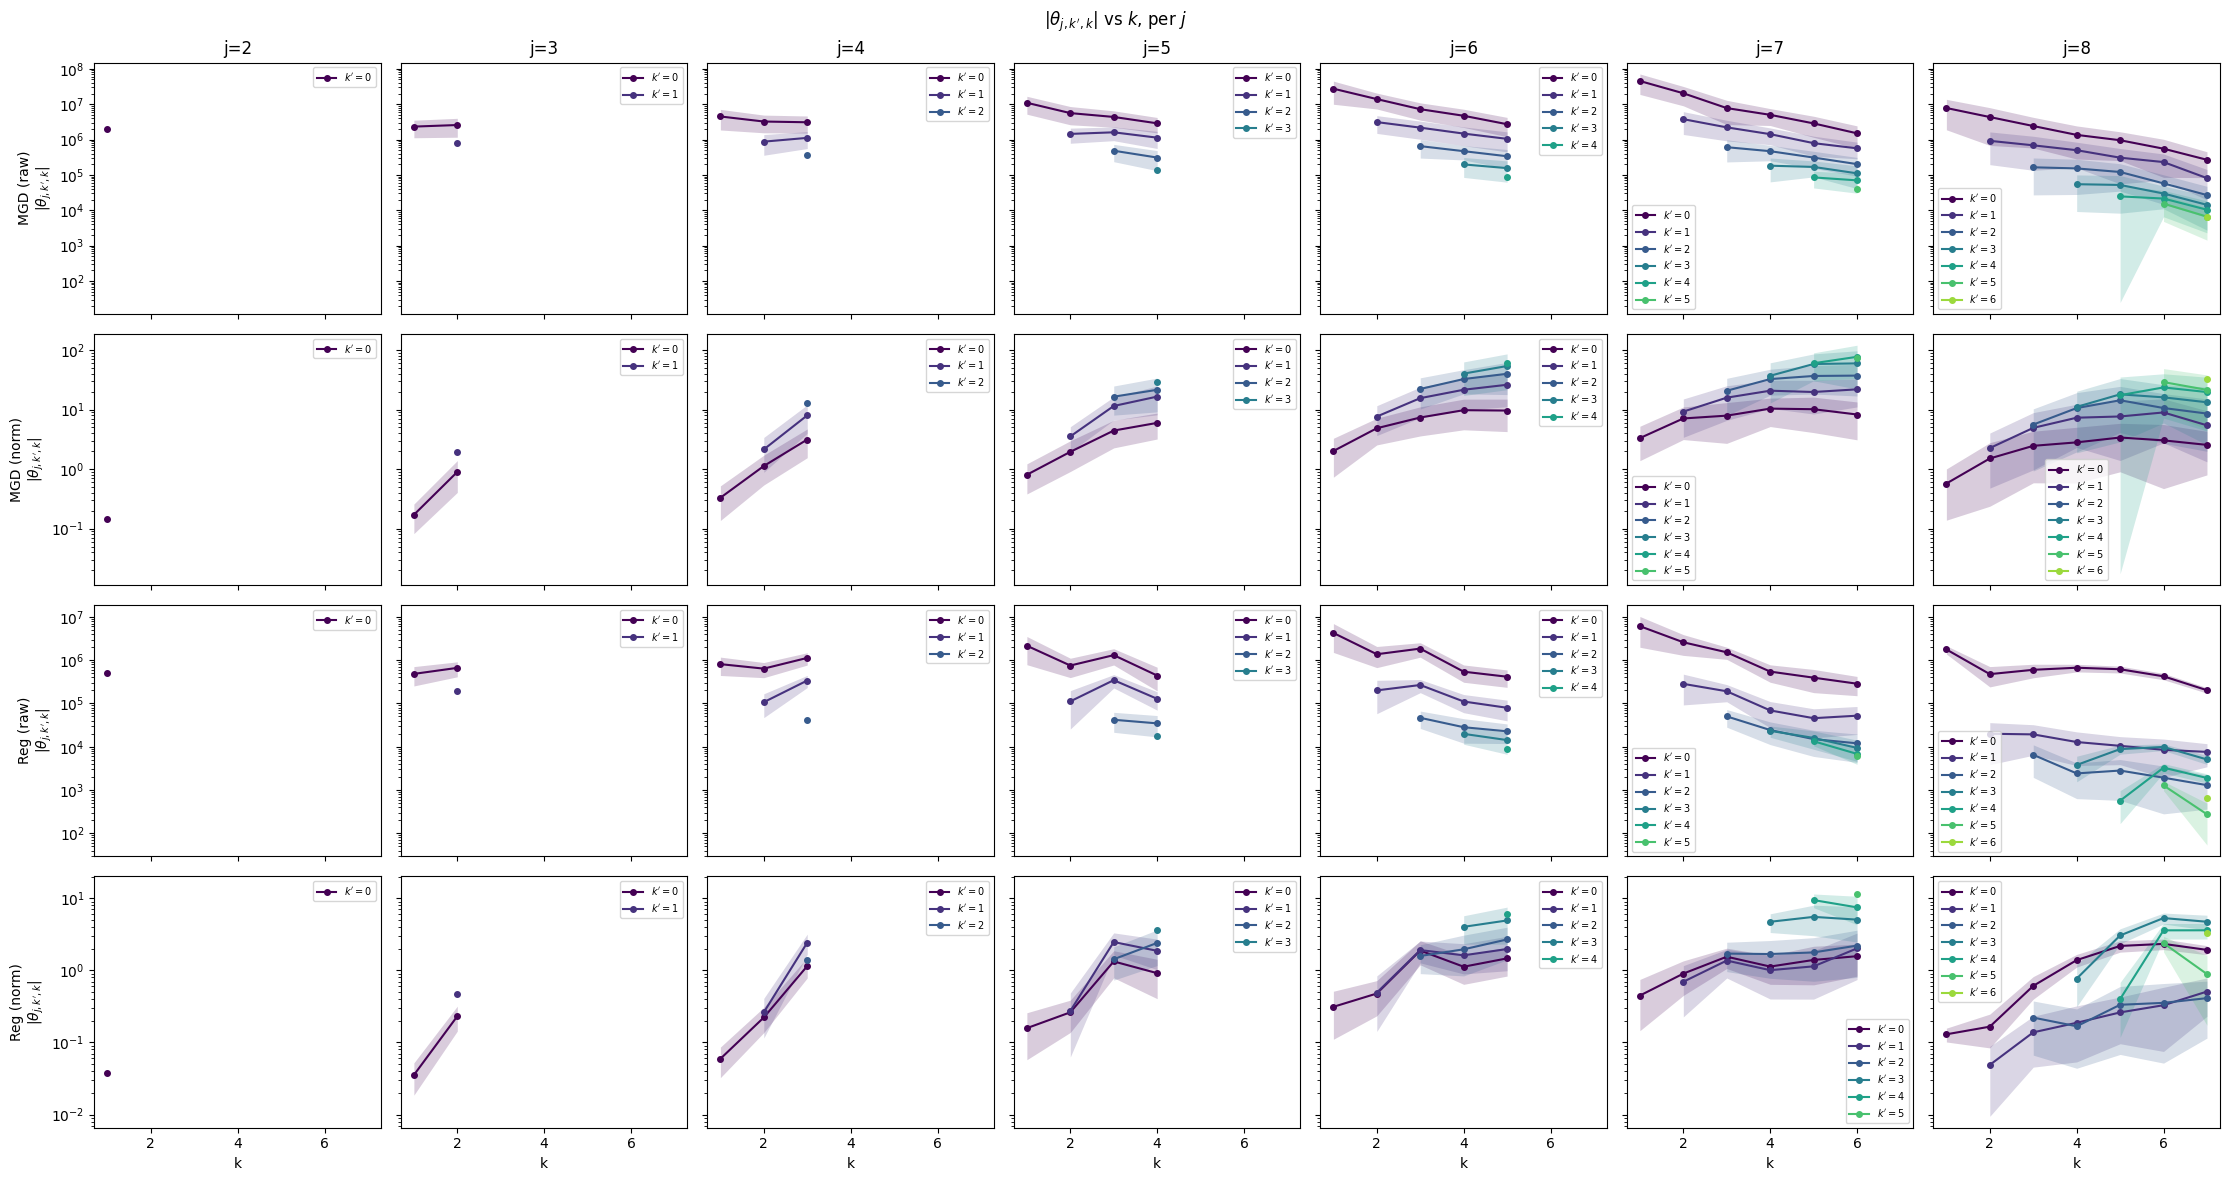

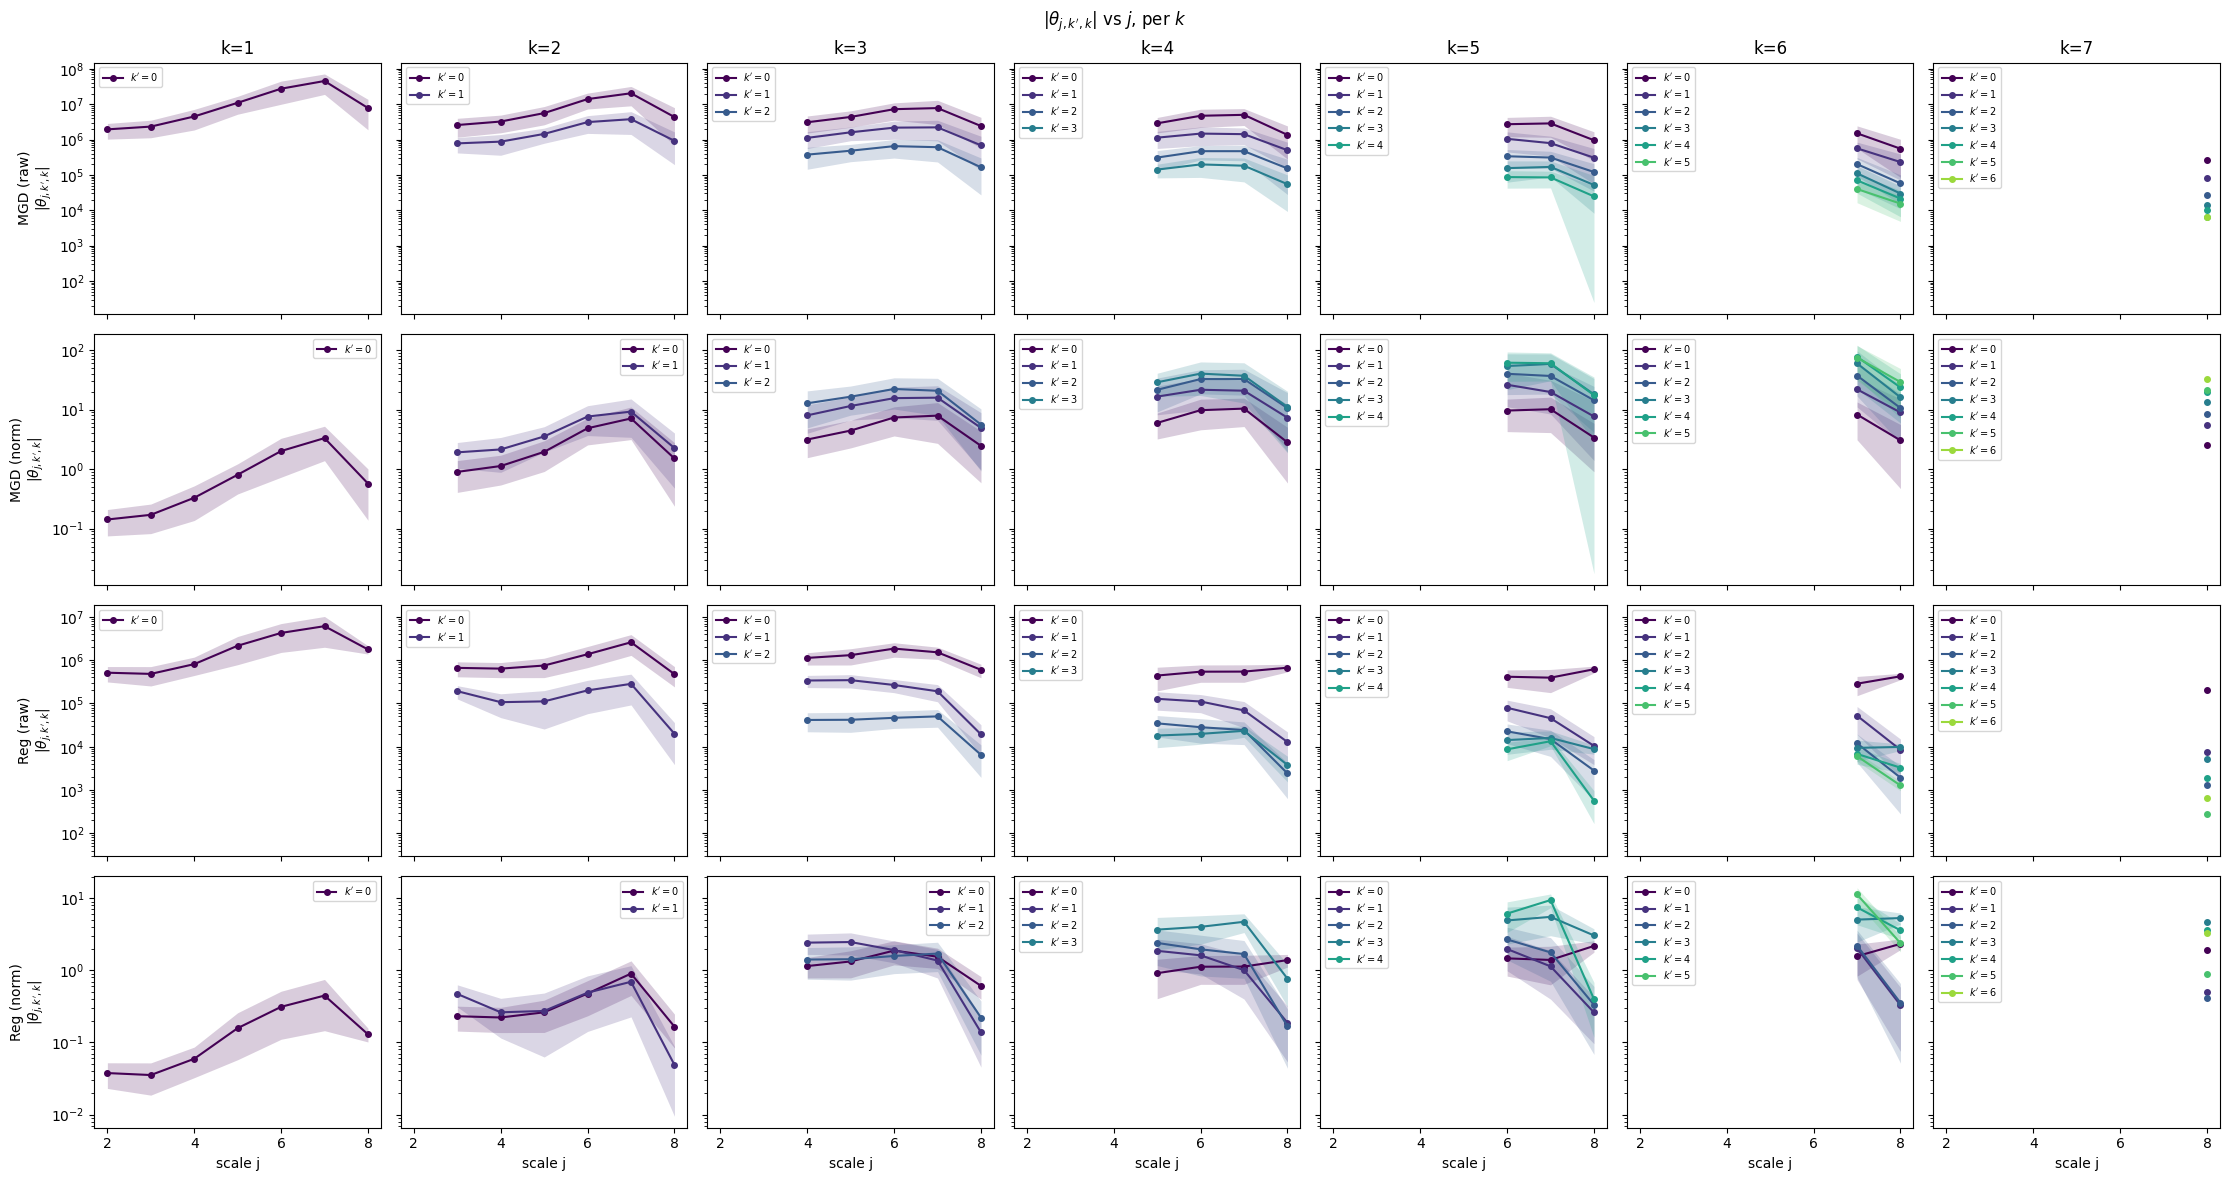

In [9]:
# Replaces the bottom section of the notebook (from
# "Build per-seed dataframes for theta_MGD and theta_reg..." onward).
# Everything above (results loading, reg_all/mgd_all, potential_ranges,
# terms, base_args, root, device, x1, filters) is unchanged. `filters` here
# is the notebook's J+1-channel single-layer filter bank
# (filters = return_Filters(M, J, 1, device=device)) -- it's only used as a
# fallback inside compute_norm_jab if a potential doesn't carry its own
# `.filters` attribute; in practice every potential you've fitted does, so
# pot_re.filters is what actually gets used.

# from theta_analysis_v2 import (
#     compute_mk, build_theta_dataframe, build_complex_theta_dataframe,
#     build_agg_cases, plot_modulus_vs_k_grid, plot_modulus_vs_j_grid,
#     build_all_averaged_vectors, find_matching_reference_potentials,
# )

REAL_KEY = "Scattering_Fourth_Order_Mod2_Real_Q1"
IMAG_KEY = "Scattering_Fourth_Order_Mod2_Imag_Q1"
COMPLEX_NAME = "Scattering_Fourth_Order_Mod2_Q1"

# ------------------------------------------------------------
# 1. Per-seed complex dataframes for the Real+i*Imag scattering coefficient
# ------------------------------------------------------------
dfs = {}              # MGD
dfs_reg = {}           # Reg
potentials_by_seed = {}  # keep each seed's FITTED potentials -- needed below,
                          # since their pruned layout is what actually matches
                          # theta_t on disk, not the nominal get_1d_potentials(...)
mk_by_seed = {}        # matching m_k vector for each seed's fitted potentials
                        # (kept as an optional fallback normalization for
                        # potentials without scattering .indices; the Mod2
                        # pair itself now normalizes via compute_norm_jab)

for key in sorted(results.keys(), key=lambda s: int(s.replace("seed", ""))):
    potentials_k = get_potentials_for_seed(key, M, base_args, root, device)
    potentials_by_seed[key] = potentials_k
    m_k = compute_mk(potentials_k, x1)
    mk_by_seed[key] = m_k

    theta_final = results[key]["theta_t"][-1]
    dfs[key] = build_complex_theta_dataframe(
        theta_final, potentials_k, REAL_KEY, IMAG_KEY, x1=x1, filters=filters,
        combined_name=COMPLEX_NAME, m_k=m_k,
        # norm_order left as None -> auto-inferred to 4 since 'Mod2' is in REAL_KEY
    )

    theta_reg_final = results[key]["Theta_reg"][-1]
    dfs_reg[key] = build_complex_theta_dataframe(
        theta_reg_final, potentials_k, REAL_KEY, IMAG_KEY, x1=x1, filters=filters,
        combined_name=COMPLEX_NAME, m_k=m_k,
    )

# ------------------------------------------------------------
# 2. |theta_complex| vs k (per j) and vs j (per k), MGD vs Reg, raw + normalized
# ------------------------------------------------------------
cases = {
    'MGD (raw)':  {'dfs': dfs,     'value_col': 'theta_complex'},
    'MGD (norm)': {'dfs': dfs,     'value_col': 'theta_complex_normalized'},
    'Reg (raw)':  {'dfs': dfs_reg, 'value_col': 'theta_complex'},
    'Reg (norm)': {'dfs': dfs_reg, 'value_col': 'theta_complex_normalized'},
}
agg_cases = build_agg_cases(cases)

%matplotlib inline 
plot_modulus_vs_k_grid(agg_cases)   # |theta_complex| vs k, one panel per j
plot_modulus_vs_j_grid(agg_cases)   # |theta_complex| vs j, one panel per k

### Compare $\theta_k m_k$ interacting and not-interacting energy components 

Using seed300's fitted potentials for MGD vectors, seed300's for Reg vectors.
L_6                                      shape=(9,)  (real)
L_6_psi                                  shape=(25,)  (real)
L_2_lowpass                              shape=(1,)  (real)
Scalar_psi_gaussianK                     shape=(70,)  (real)
Scalar_morlet_gaussianK                  shape=(27,)  (real)
Scattering_Fourth_Order_Mod2_Q1          shape=(84,)  (complex)
K                4
J                25
num_coefficients 70
Keff             tensor shape=(25,) dtype=torch.int64
active           tensor shape=(25, 4) dtype=torch.bool
active_flat      tensor shape=(70,) dtype=torch.int64
scale            tensor shape=(25, 4) dtype=torch.float32
alpha            tensor shape=(25, 4) dtype=torch.float32
cuts             tensor shape=(25, 3) dtype=torch.float32
pi               tensor shape=(25, 4) dtype=torch.float32
sw               tensor shape=(25, 3) dtype=torch.float32
stat_scale       tensor shape=(70,) dtype=t

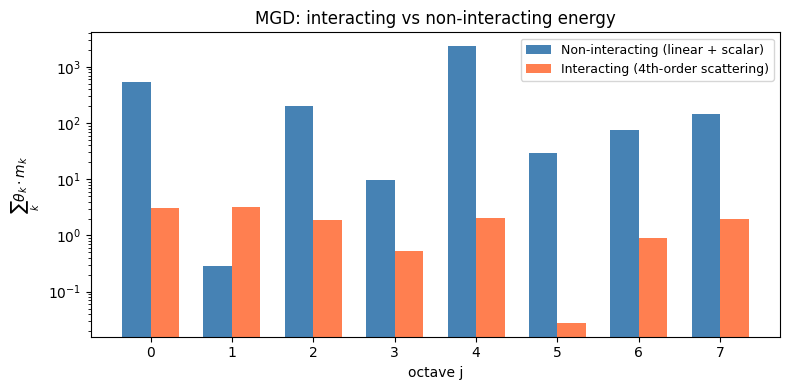

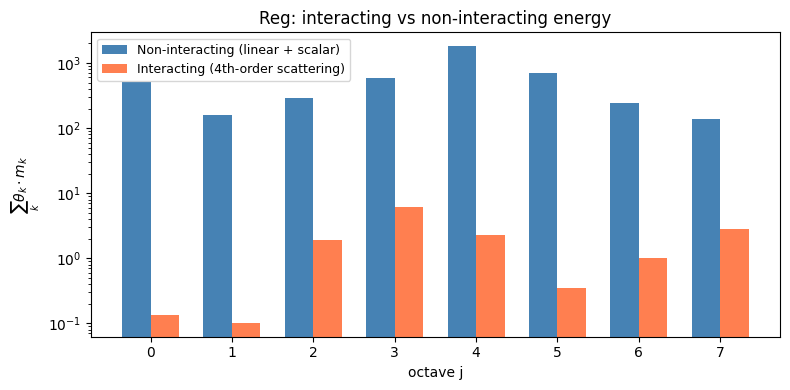

theta_k stdPhi_k, all positive


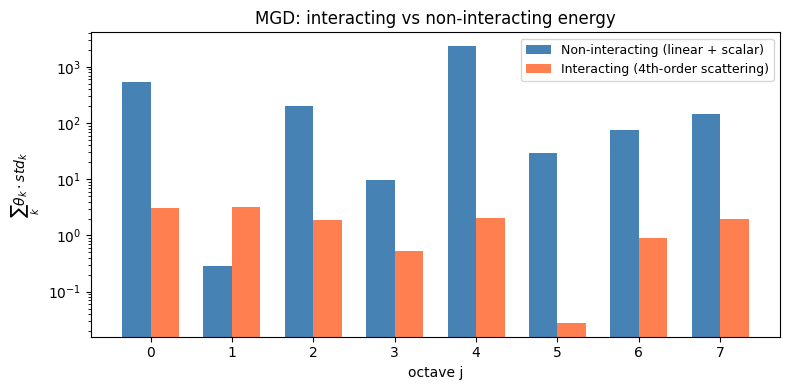

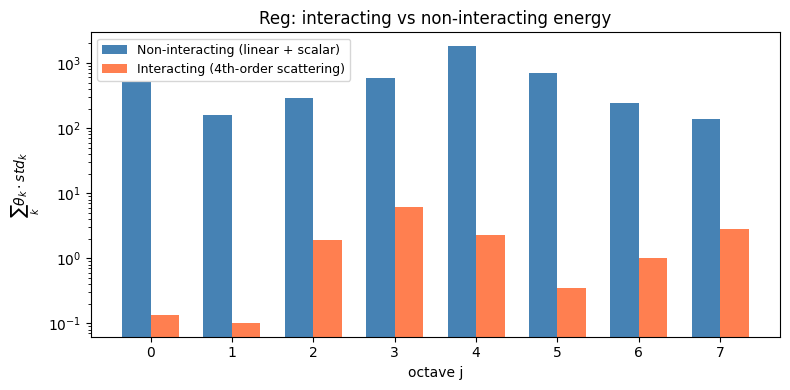

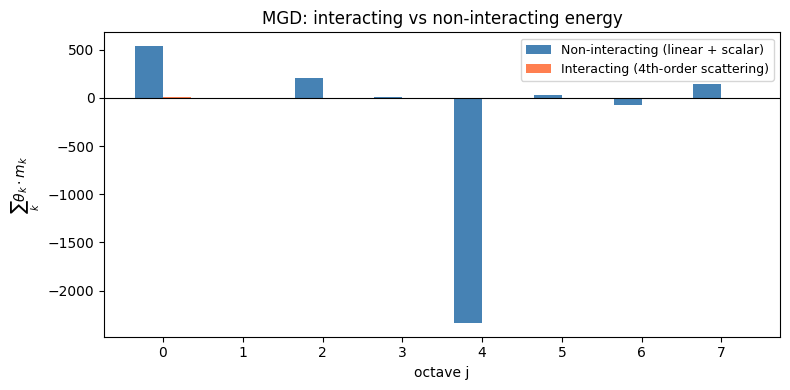

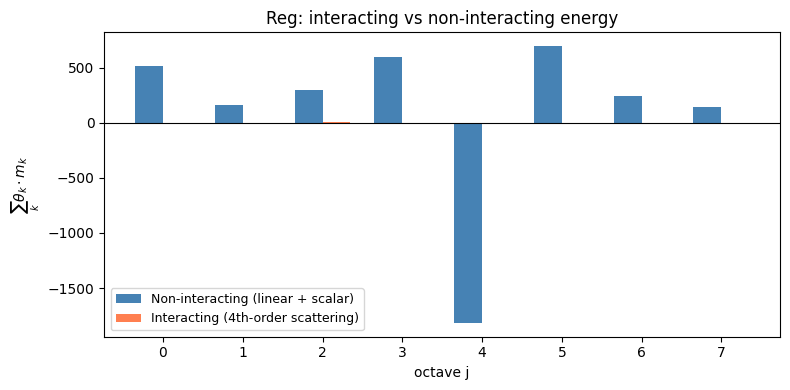

In [10]:

# ------------------------------------------------------------
# 3. Readable, seed-averaged theta vectors for every potential
#    (Real_Q1 + i*Imag_Q1 collapsed into one complex vector; everything
#    else -- L_6, L_6_psi, L_2_lowpass, Scalar_psi_gaussianK,
#    Scalar_morlet_gaussianK -- stays real)
#
#    Use a reference seed's FITTED potentials (whichever one's pruned
#    layout actually sums to mgd_all's column count) instead of the
#    nominal `potentials` from get_1d_potentials(...) at the top of the
#    notebook -- that nominal one reflects theoretical, un-pruned sizes
#    and will trip the sum(dims) != n_theta assertion.
# ------------------------------------------------------------
real_imag_pairs = [(REAL_KEY, IMAG_KEY, COMPLEX_NAME)]

ref_seed_mgd, ref_potentials_mgd, _ = find_matching_reference_potentials(mgd_all, potentials_by_seed)
ref_seed_reg, ref_potentials_reg, _ = find_matching_reference_potentials(reg_all, potentials_by_seed)
print(f"Using {ref_seed_mgd}'s fitted potentials for MGD vectors, {ref_seed_reg}'s for Reg vectors.")

mgd_vectors = build_all_averaged_vectors(mgd_all, ref_potentials_mgd, terms, real_imag_pairs=real_imag_pairs)
reg_vectors = build_all_averaged_vectors(reg_all, ref_potentials_reg, terms, real_imag_pairs=real_imag_pairs)

# e.g.:
#   mgd_vectors['L_6']                          -> real, shape (9,)
#   mgd_vectors['L_6_psi']                      -> real, shape (25,)
#   mgd_vectors['Scattering_Fourth_Order_Mod2_Q1']  -> complex
#   reg_vectors['Scalar_psi_gaussianK']         -> real

for name, vec in mgd_vectors.items():
    kind = 'complex' if np.iscomplexobj(vec) else 'real'
    print(f"{name:40s} shape={vec.shape}  ({kind})")

# ------------------------------------------------------------
# 4. Matching m_k vectors + octave-level "interacting vs non-interacting"
#    energy comparison: theta_k * m_k, summed within each octave j.
#
#    Non-interacting: L_6, L_6_psi, Scalar_psi_gaussianK,
#    Scalar_morlet_gaussianK (octave-structured) + L_2_lowpass (pure scalar).
#    Interacting: the Real+i*Imag 4th-order scattering potential.
#
#    "psi"-family potentials use Q=3, "morlet"-family use Q=1 -- adjust
#    potential_QJ below if that naming-based guess is wrong for your setup.
# ------------------------------------------------------------

# mk_all must be stacked in the SAME seed order used for mgd_all/reg_all
# (seeds_sorted). If mk_by_seed's key format ("seedN") differs from
# seeds_sorted's (plain ints), adjust the lookup below to match.
mk_all = torch.stack([torch.as_tensor(mk_by_seed[f"seed{s}"]) for s in seeds_sorted])
assert mk_all.shape[0] == mgd_all.shape[0], (
    "mk_all and mgd_all have different seed counts -- their seed sets/order "
    "must match for the vectors below to line up."
)

ref_seed_mk, ref_potentials_mk, _ = find_matching_reference_potentials(mk_all, potentials_by_seed)
mk_vectors = build_all_averaged_vectors(mk_all, ref_potentials_mk, terms, real_imag_pairs=real_imag_pairs)

# --- FIRST: sanity-check the Scalar_* potentials' channel structure on a
# real, fitted object before trusting anything below. Run this once and
# read the output -- Keff/active_flat should be populated (unlike the
# unfitted `potentials` dict), and num_coefficients should equal
# active_flat.sum() / Keff.sum().
inspect_fitted_scalar_potential(ref_potentials_mgd["Scalar_psi_gaussianK"])
inspect_fitted_scalar_potential(ref_potentials_mgd["Scalar_morlet_gaussianK"])

J = base_args.J
potential_specs = {
    'L_6':     ('QJ', 1),
    'L_6_psi': ('QJ', 3),
    'Scalar_morlet_gaussianK': ('scalar', ref_potentials_mgd["Scalar_morlet_gaussianK"], 1),
    'Scalar_psi_gaussianK':    ('scalar', ref_potentials_mgd["Scalar_psi_gaussianK"], 3),
}
# j2 (coarse, second-layer) index for each scattering coefficient, decoded
# from a real potential whose layout matches theta_vectors[COMPLEX_NAME] --
# i.e. the reference potential used to build mgd_vectors/reg_vectors, not
# the nominal one. Uses decode_mod2_stq (NOT decode_jab): verified against
# Scattering_Fourth_Order_Mod2_Real_1d's actual forward()/fit_micro tensor
# shapes, j2 ranges over [0,J] (J+1 values incl. low-pass) -- decode_jab
# assumed a structurally different, incompatible axis layout for this
# potential family. Ranges over [0,J], so build_octave_energy_comparison
# groups it into J+1 bins internally and reports the low-pass one
# separately (energy_dict['interacting_lowpass']).
_, s1_indices_scatter, s2_indices_scatter = decode_mod2_stq(ref_potentials_mgd[REAL_KEY], verbose=False)
Q_scatter = ref_potentials_mgd[REAL_KEY].Q   # =1 for the _Q1 potentials used here

energy_mgd = build_octave_energy_comparison(
    mgd_vectors, mk_vectors, potential_specs,
    interacting_key=COMPLEX_NAME,
    s1_indices_interacting=s1_indices_scatter, s2_indices_interacting=s2_indices_scatter,
    Q_interacting=Q_scatter, J=J,
    scalar_potentials=['L_2_lowpass'],
)
energy_reg = build_octave_energy_comparison(
    reg_vectors, mk_vectors, potential_specs,
    interacting_key=COMPLEX_NAME,     
    s1_indices_interacting=s1_indices_scatter, s2_indices_interacting=s2_indices_scatter,
    Q_interacting=Q_scatter, J=J,
    scalar_potentials=['L_2_lowpass'],
)

energy_mgd_std = build_octave_energy_comparison(
    mgd_vectors, mk_vectors, potential_specs,
    interacting_key=COMPLEX_NAME,     
    s1_indices_interacting=s1_indices_scatter, s2_indices_interacting=s2_indices_scatter,
    Q_interacting=Q_scatter, J=J,
    scalar_potentials=['L_2_lowpass'],  energy_kind='std', 
)
energy_reg_std = build_octave_energy_comparison(
    reg_vectors, mk_vectors, potential_specs,
    interacting_key=COMPLEX_NAME,     
    s1_indices_interacting=s1_indices_scatter, s2_indices_interacting=s2_indices_scatter,
    Q_interacting=Q_scatter, J=J,
    scalar_potentials=['L_2_lowpass'],  energy_kind='std', 
)

print("\nMGD -- non-interacting energy per octave:", energy_mgd['non_interacting_total'])
print("MGD -- interacting energy per octave:    ", energy_mgd['interacting'])
print("MGD -- non-interacting low-pass total:   ", energy_mgd['non_interacting_lowpass_total'])

%matplotlib inline 
print("theta_k m_k, all positive") 
plot_octave_energy_comparison(energy_mgd, all_positive = True, title='MGD: interacting vs non-interacting energy')
plot_octave_energy_comparison(energy_reg, all_positive = True, title='Reg: interacting vs non-interacting energy')

print("theta_k stdPhi_k, all positive") 
plot_octave_energy_comparison(energy_mgd_std, all_positive = True, title='MGD: interacting vs non-interacting energy')
plot_octave_energy_comparison(energy_reg_std, all_positive = True, title='Reg: interacting vs non-interacting energy')

plot_octave_energy_comparison(energy_mgd, title='MGD: interacting vs non-interacting energy')
plot_octave_energy_comparison(energy_reg, title='Reg: interacting vs non-interacting energy')

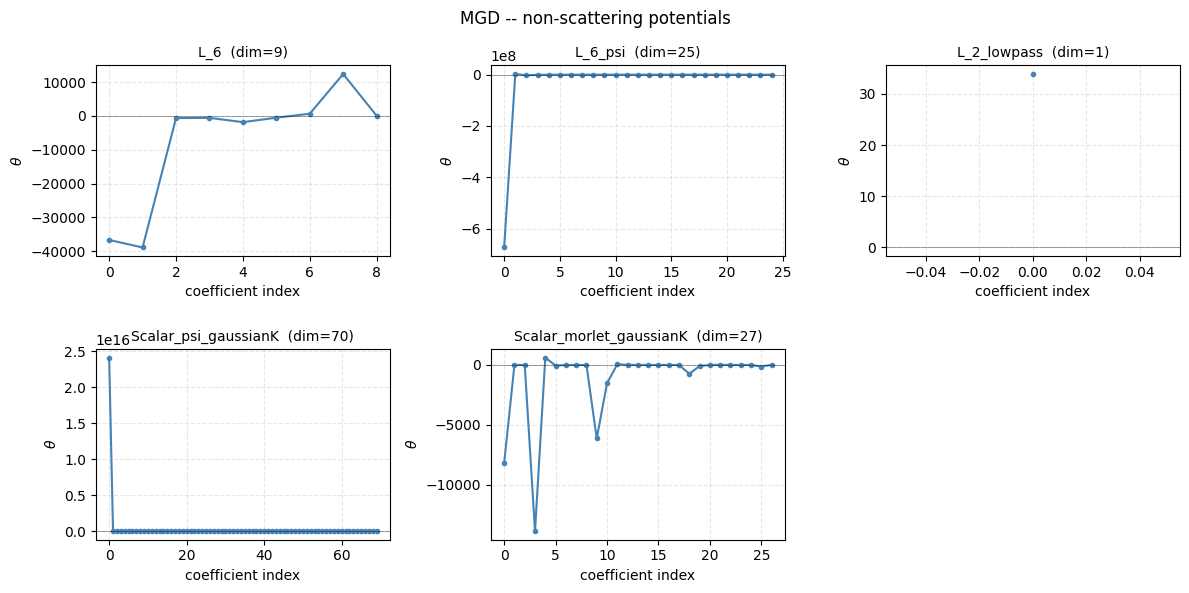

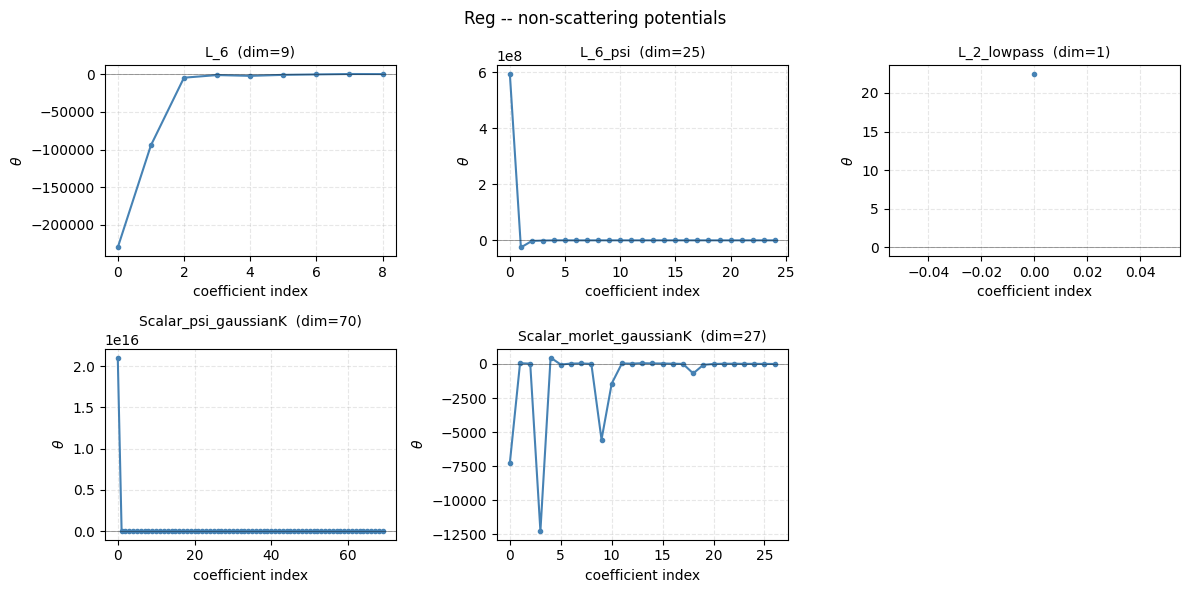

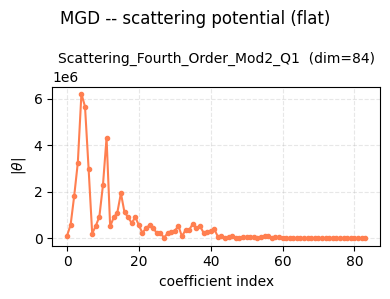

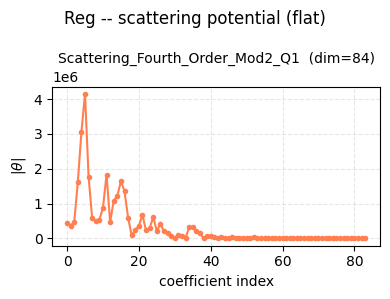

In [11]:
non_scattering_names = [k for k in mgd_vectors.keys() if k != COMPLEX_NAME]

plot_theta_by_potential(mgd_vectors, potential_names=non_scattering_names,
                         title='MGD -- non-scattering potentials')
plot_theta_by_potential(reg_vectors, potential_names=non_scattering_names,
                         title='Reg -- non-scattering potentials')

plot_theta_by_potential(mgd_vectors, potential_names=[COMPLEX_NAME], ncols=1,
                         title='MGD -- scattering potential (flat)')
plot_theta_by_potential(reg_vectors, potential_names=[COMPLEX_NAME], ncols=1,
                         title='Reg -- scattering potential (flat)')

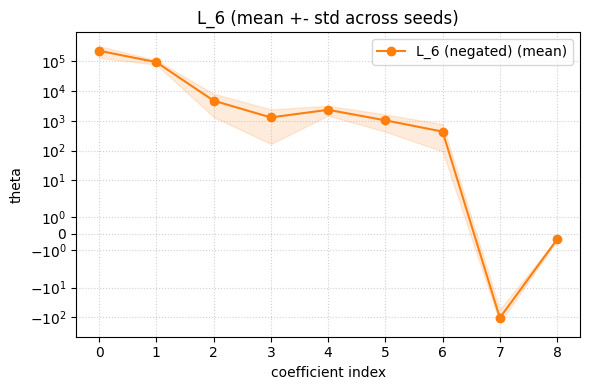

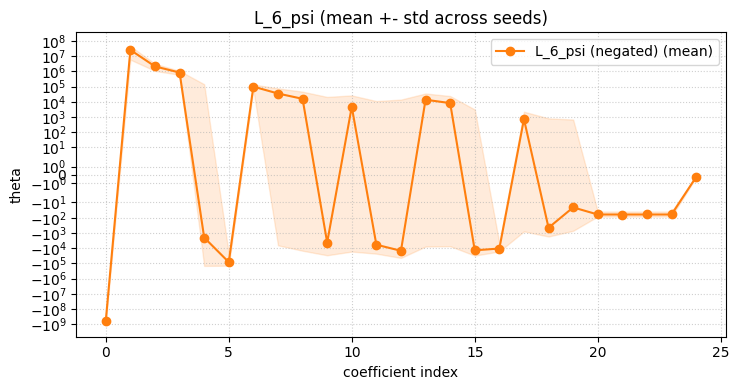

In [12]:
ref_seed_reg, ref_potentials_reg, _ = find_matching_reference_potentials(reg_all, potentials_by_seed)
%matplotlib inline 
plot_linear_potential_mean_std(reg_all, ref_potentials_reg, 'L_6', terms, sign=-1)
plot_linear_potential_mean_std(reg_all, ref_potentials_reg, 'L_6_psi', terms, sign=-1)

## Sum of L6 psi and L6 terms 

[[ True False False  True False  True False  True  True]
 [ True False False False  True  True False  True  True]
 [ True False False  True  True  True  True  True  True]
 [ True False False  True  True  True False  True  True]
 [ True False False  True  True  True  True  True  True]
 [ True False False False False  True False  True  True]
 [ True False False False False  True False  True  True]
 [ True False False False  True  True False  True  True]
 [ True False False  True False  True False  True  True]
 [ True False False False False False  True  True  True]
 [ True False False  True False  True  True  True  True]
 [ True False  True  True  True  True  True  True  True]
 [ True False False  True  True  True False  True  True]
 [ True False False False  True False  True  True  True]
 [ True False False  True False  True False  True  True]
 [ True False False  True  True False  True  True  True]
 [ True False False False False  True  True  True  True]
 [ True False False False False

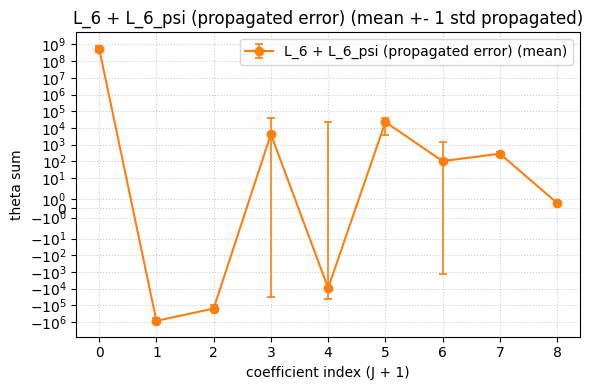

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_linear_potential_SUM_mean_std(theta_all, potentials,
                                       target_keys=('L_6', 'L_6_psi'),
                                       label=None, sign=1, known_dims=None,
                                       color='tab:orange', yscale='symlog',
                                       capsize=3):
    """
    Mean and propagated 1 std error bars for the SUM of two potentials.
    
    Explicitly uses error propagation (quadrature sum):
    1. Computes mean & std across seeds independently for both potentials.
    2. Groups 3 consecutive terms in key2 (3*J) via quadrature sum for stds:
       std_grouped = sqrt(std_a^2 + std_b^2 + std_c^2).
    3. Combines key1 and grouped key2 via quadrature sum:
       std_total = sqrt(std_key1^2 + std_grouped^2).
    """
    theta_np = theta_all.detach().cpu().numpy() if torch.is_tensor(theta_all) else np.asarray(theta_all)
    n_features = theta_np.shape[-1]
    
    col_map = theta_column_map(potentials, n_features, known_dims=known_dims, verbose=False)
    
    for key in target_keys:
        if key not in col_map:
            raise KeyError(f"'{key}' not found in potentials: {list(potentials.keys())}")
            
    key1, key2 = target_keys
    start1, dim1 = col_map[key1]
    start2, dim2 = col_map[key2]
    
    slice1 = theta_np[:, start1:start1+dim1]      # (nseed, J+1)
    slice2 = theta_np[:, start2:start2+dim2]      # (nseed, 3J+1)
    
    J = dim1 - 1
    
    # aggregate psi within each seed
    psi = slice2[:, :3*J].reshape(-1, J, 3).sum(axis=-1)
    
    # append the constant
    psi = np.concatenate(
        [psi, slice2[:, -1][:, None]],
        axis=1
    )
    
    # total theta for each seed
    theta_total = sign * (slice1 + psi)
    print(theta_total > 0 ) 
    
    # now statistics
    final_mean = theta_total.mean(axis=0)
    final_std = theta_total.std(axis=0)
    
    for i, (m, s) in enumerate(zip(final_mean, final_std)):
        if m > 0:
            z = m / s if s > 0 else np.inf
            print(f"{i:2d}: mean={m:.4g}, std={s:.4g}, z={z:.2f}")
    
    # Plotting
    x = np.arange(dim1)
    default_name = f"{key1} + {key2} (propagated error)"
    label = label or f"{default_name}{' (negated)' if sign == -1 else ''} (mean)"
    
    plt.figure(figsize=(max(6, dim1 * 0.3), 4))
    plt.errorbar(
        x, final_mean, yerr=final_std, fmt='-o', color=color, label=label,
        capsize=capsize, elinewidth=1.2, capthick=1.2
    )
    
    if yscale != 'linear':
        plt.yscale(yscale)
        
    plt.title(f'{default_name} (mean +- 1 std propagated)')
    plt.xlabel('coefficient index (J + 1)')
    plt.ylabel('theta sum')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    if (final_mean < 0).any() and yscale == 'log':
        print(f"WARNING: {default_name} has negative values but yscale='log' -- "
              f"those points are invisible on the plot above. Use 'symlog' or 'linear'.")
        
plot_linear_potential_SUM_mean_std(reg_all, ref_potentials_reg) 

In [18]:
list(reference_potentials.keys())

['L_6',
 'L_6_psi',
 'L_2_lowpass',
 'Scalar_psi_gaussianK',
 'Scalar_morlet_gaussianK',
 'Scattering_Fourth_Order_Mod2_Real_Q1',
 'Scattering_Fourth_Order_Mod2_Imag_Q1']

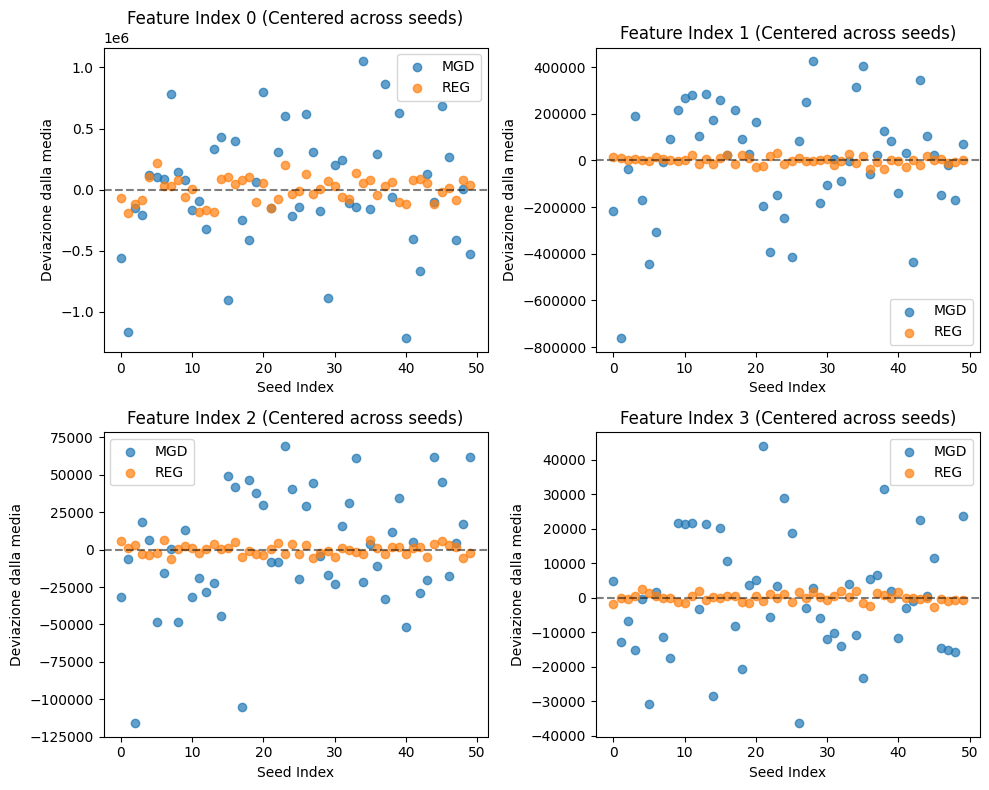

In [19]:
# ------------------------------------------------------------
# Compute theta column ranges for each potential
# ------------------------------------------------------------
for name, X in {"Theta_reg": theta_reg, "Theta_MGD": theta_mgd}.items():
    mean = X.mean(axis=0)
    # ddof=1 per varianza/std campionaria corretta
    std = X.std(axis=0, ddof=1)
    var = std**2
    cv = std / (np.abs(mean) + eps)
    rel_var = var / (mean**2 + eps)
    snr = np.abs(mean) / (std + eps)

    stats[name] = dict(
        mean=mean, std=std, var=var, cv=cv, rel_var=rel_var, snr=snr
    )
# ------------------------------------------------------------
# 2. Correzione Loop Feature (Scatter plot anziché line plot)
# ------------------------------------------------------------
# Plot solo dei primi 4 parametri a titolo di esempio (evitiamo di bloccare il notebook)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    # Centriamo rispetto alla media delle seed
    mgd_centered = theta_mgd[:, i] - stats["Theta_MGD"]["mean"][i]
    reg_centered = theta_reg[:, i] - stats["Theta_reg"]["mean"][i]
    
    seeds_idx = np.arange(n_seeds)
    ax.scatter(seeds_idx, mgd_centered, label="MGD", color="tab:blue", alpha=0.7)
    ax.scatter(seeds_idx, reg_centered, label="REG", color="tab:orange", alpha=0.7)
    ax.axhline(0, color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"Feature Index {i} (Centered across seeds)")
    ax.set_xlabel("Seed Index")
    ax.set_ylabel("Deviazione dalla media")
    ax.legend()
plt.tight_layout()
plt.show()

potential_colors = {
    "L_6": "tab:blue",
    "L_6_psi": "tab:olive", 
    "L_2_lowpass": "tab:green",
    "Scattering_Fourth_Order_Mod2_Real_Q1": "tab:red",
    "Scattering_Fourth_Order_Mod2_Imag_Q1": "tab:purple",
    "Scalar_psi_gaussianK": "tab:orange",
    "Scalar_morlet_gaussianK": "tab:cyan", 
}


Theta_reg shape : (50, 272)
Theta_MGD shape : (50, 272)


,Theta_reg mean variance,Theta_MGD mean variance,Theta_reg median variance,Theta_MGD median variance,Theta_reg mean CV,Theta_MGD mean CV,Theta_reg mean SNR,Theta_MGD mean SNR
0,4.455270e+24,1.780510e+26,35366816.0,1.463698e+10,5.504886,34.499317,51.000996,6.858085


Mean correlation : 0.09240991916386719
Median correlation : 0.0757172126264172
{'L_6': (0, 9), 'L_6_psi': (9, 34), 'L_2_lowpass': (34, 35), 'Scalar_psi_gaussianK': (35, 105), 'Scalar_morlet_gaussianK': (105, 132), 'Scattering_Fourth_Order_Mod2_Real_Q1': (132, 216), 'Scattering_Fourth_Order_Mod2_Imag_Q1': (216, 272)}
{'L_6': (0, 9), 'L_6_psi': (9, 34), 'L_2_lowpass': (34, 35), 'Scattering_Fourth_Order_Mod2_Real_Q1': (35, 119), 'Scattering_Fourth_Order_Mod2_Imag_Q1': (119, 175), 'Scalar_psi_gaussianK': (175, 245), 'Scalar_morlet_gaussianK': (245, 272)}


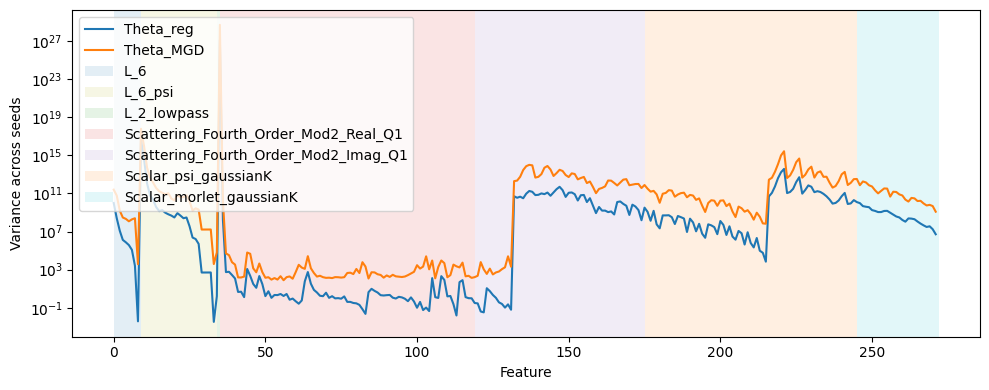

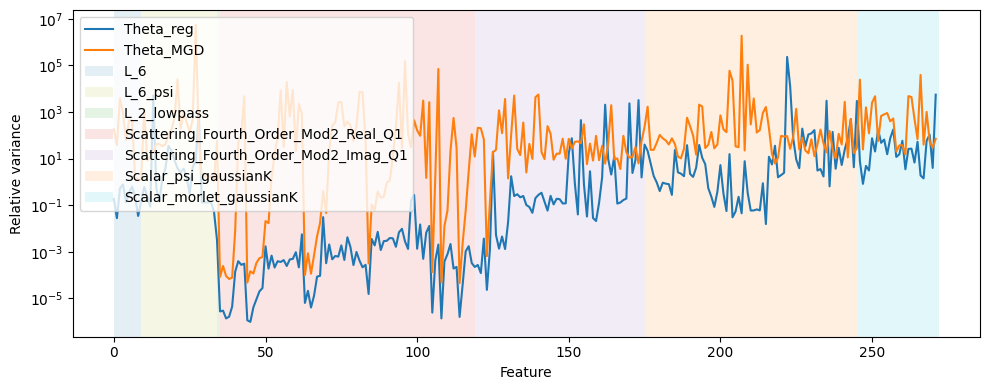

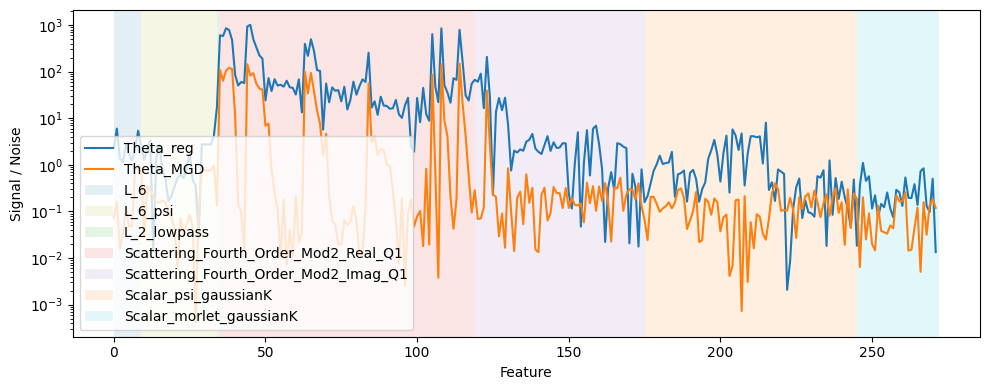

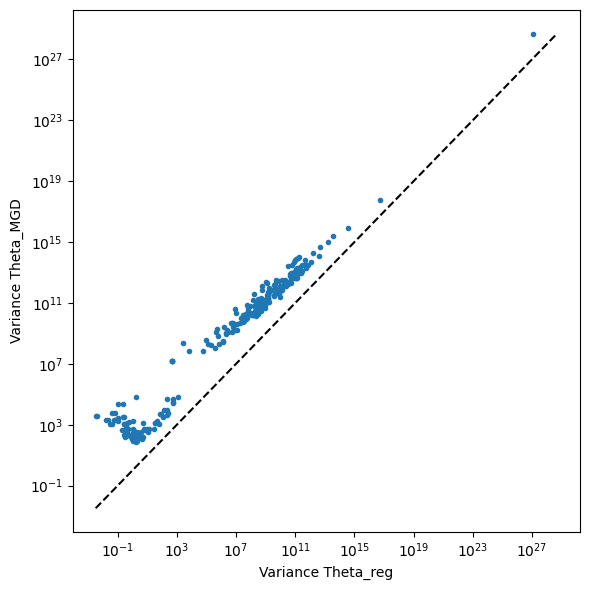

Largest Theta_reg variances
35 1.21183354e+27
9 5.0386143e+16
10 391654070000000.0
221 37034048000000.0
220 16397191000000.0
226 4963517300000.0
219 3912058800000.0
225 1534956300000.0
11 1083953900000.0
229 687397900000.0

Largest Theta_MGD variances
35 4.8429866e+28
9 6.011462e+17
10 8755951000000000.0
221 2636291500000000.0
220 957011300000000.0
226 455778170000000.0
225 186865790000000.0
219 115885740000000.0
137 98873770000000.0
138 87503020000000.0


In [20]:
import pandas as pd

# ------------------------------------------------------------
# Use the currently loaded runs directly — no file load.
# reg_all / mgd_all were built earlier from `results` via
# torch.stack([final_theta_reg[s] for s in seeds_sorted]) etc.
# ------------------------------------------------------------
seeds = seeds_sorted

theta_reg = reg_all.detach().cpu().numpy()
theta_mgd = mgd_all.detach().cpu().numpy()

print("Theta_reg shape :", theta_reg.shape)
print("Theta_MGD shape :", theta_mgd.shape)

n_seeds, n_features = theta_reg.shape
assert n_features == n_features_reg == n_features_mgd, (
    "reg_all/mgd_all feature dim doesn't match n_features_reg/n_features_mgd "
    "computed earlier — check seeds_sorted and results are in sync."
)

%matplotlib inline
eps = 1e-12

stats = {}

for name, X in {
    "Theta_reg": theta_reg,
    "Theta_MGD": theta_mgd,
}.items():
    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    var = std**2
    cv = std / (np.abs(mean) + eps)
    rel_var = var / (mean**2 + eps)
    snr = np.abs(mean) / (std + eps)

    stats[name] = dict(mean=mean, std=std, var=var, cv=cv, rel_var=rel_var, snr=snr)

summary = pd.DataFrame({
    "Theta_reg mean variance": [stats["Theta_reg"]["var"].mean()],
    "Theta_MGD mean variance": [stats["Theta_MGD"]["var"].mean()],
    "Theta_reg median variance": [np.median(stats["Theta_reg"]["var"])],
    "Theta_MGD median variance": [np.median(stats["Theta_MGD"]["var"])],
    "Theta_reg mean CV": [stats["Theta_reg"]["cv"].mean()],
    "Theta_MGD mean CV": [stats["Theta_MGD"]["cv"].mean()],
    "Theta_reg mean SNR": [stats["Theta_reg"]["snr"].mean()],
    "Theta_MGD mean SNR": [stats["Theta_MGD"]["snr"].mean()],
})
display(summary)

corrs = np.array([
    np.corrcoef(theta_reg[:, j], theta_mgd[:, j])[0, 1]
    for j in range(n_features)
])
print("Mean correlation :", np.nanmean(corrs))
print("Median correlation :", np.nanmedian(corrs))

# ------------------------------------------------------------
# potential_ranges from the live reference potentials (find_matching_reference_potentials
# already resolves against reg_all/potentials_by_seed, both in-memory)
# ------------------------------------------------------------
reference_seed_name, reference_potentials, _ = find_matching_reference_potentials(
    reg_all, potentials_by_seed
)

sizes = {name: p.num_coefficients for name, p in reference_potentials.items()}

potential_ranges = {}
start = 0
for name, dim in sizes.items():          # <- natural order from reference_potentials
    potential_ranges[name] = (start, start + dim)
    start += dim

# sanity check: every potential we're about to plot has a color assigned
missing_colors = [name for name in potential_ranges if name not in potential_colors]
if missing_colors:
    raise KeyError(
        f"No entry in potential_colors for: {missing_colors} — "
        f"add colors for these or they won't be shaded in the plots."
    )

assert start == n_features_reg == n_features_mgd, (
    f"Potential-range total ({start}) doesn't match theta_reg/theta_MGD feature "
    f"dimension ({n_features_reg}). {reference_seed_name}'s pruning differs from "
    f"the pooled theta arrays — check all seeds in seeds_sorted share active regions."
)
print(potential_ranges)

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Variance across seeds")
ymin, ymax = plt.ylim()

# Resolve a reference seed whose fitted/pruned potentials actually sum to
# n_features_reg (== n_features_mgd) — same mechanism used later for
# ref_potentials_mgd / ref_potentials_reg, done here first since we need
# it earlier for the variance/rel_var/snr plots.
reference_seed_name, reference_potentials, _ = find_matching_reference_potentials(
    reg_all, potentials_by_seed
)

sizes = {name: p.num_coefficients for name, p in reference_potentials.items()}

potential_ranges = {}
start = 0
for name in potential_colors.keys():
    if name not in sizes:
        raise KeyError(
            f"'{name}' in potential_colors but missing from {reference_seed_name}'s "
            f"fitted potentials — check spelling against `terms`."
        )
    dim = sizes[name]
    potential_ranges[name] = (start, start + dim)
    start += dim

total_from_potentials = start
assert total_from_potentials == n_features_reg == n_features_mgd, (
    f"Potential-range total ({total_from_potentials}) doesn't match the actual "
    f"feature dimension from disk (theta_reg={n_features_reg}, theta_MGD={n_features_mgd}). "
    f"This means {reference_seed_name}'s pruning differs from the pooled theta arrays — "
    f"check that all seeds in `seeds_sorted` were fit with the same active regions."
)

print(potential_ranges)

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["rel_var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["rel_var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Relative variance")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))

plt.plot(stats["Theta_reg"]["snr"], label="Theta_reg")
plt.plot(stats["Theta_MGD"]["snr"], label="Theta_MGD")
plt.yscale("log") 
plt.xlabel("Feature")
plt.ylabel("Signal / Noise")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))

plt.loglog(
    stats["Theta_reg"]["var"],
    stats["Theta_MGD"]["var"],
    "."
)

xmin = min(
    stats["Theta_reg"]["var"].min(),
    stats["Theta_MGD"]["var"].min()
)
xmax = max(
    stats["Theta_reg"]["var"].max(),
    stats["Theta_MGD"]["var"].max()
)

plt.plot([xmin,xmax],[xmin,xmax],"k--")

plt.xlabel("Variance Theta_reg")
plt.ylabel("Variance Theta_MGD")
plt.tight_layout()
plt.show()

idx = np.argsort(stats["Theta_reg"]["var"])[::-1]

print("Largest Theta_reg variances")
for i in idx[:10]:
    print(i, stats["Theta_reg"]["var"][i])

print()

idx = np.argsort(stats["Theta_MGD"]["var"])[::-1]

print("Largest Theta_MGD variances")
for i in idx[:10]:
    print(i, stats["Theta_MGD"]["var"][i])